# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)

# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# To build models for prediction
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# For Hyperparameters
from sklearn.model_selection import GridSearchCV


# To check model performance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report)

from sklearn import metrics


## **Loading the data**

In [2]:
#Import data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Read the healthcare dataset file
data = pd.read_csv("/content/drive/MyDrive/MIT - Great Learning/05 - Classification and Hypothesis Testing/06 - Project Assessment - Classification and Hypothesis Testing/02 - Dataset - Potential Customers Prediction.csv")

In [4]:
# Copying data to another variable to avoid any changes to original data
data_copy = data.copy()

## Data Overview

- Observations
- Sanity checks

In [5]:
# View the first 5 rows of the dataset
data.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [6]:
# View the last 5 rows of the dataset
data.tail()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.075,Phone Activity,No,No,No,No,No,0


In [7]:
# Understand the shape of the data
print(f'The dataset has {data.shape[0]} rows and {data.shape[1]} columns.')

The dataset has 4612 rows and 15 columns.


In [8]:
# Checking duplicated values
data.duplicated().sum()

np.int64(0)

There are not duplicated values in the dataset.

In [9]:
# Checking the info of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

**Observations:**

- Age, website_visits, time_spent_on_website, page_views_per_visit adn status   are of numeric data type and the rest of the columns are of object data type.
- The number of non-null values is the same as the total number of entries in the data, there are no null values (no missing values).
- The column ID is an identifier for ID of the lead in the data. This column will not help with our analysis so we can drop it.

In [10]:
# To view ID
data['ID'].value_counts()

,count
ID,
EXT4612,1
EXT001,1
EXT002,1
EXT003,1
EXT4596,1
...,...
EXT009,1
EXT008,1
EXT007,1


In [11]:
# To confirm that all of the values are unique
data['ID'].nunique()

4612

In [12]:
# Dropping hte columns 'ID
data.drop('ID', axis=1, inplace=True)

In [13]:
# Checking the descriptive statistics of the numerical columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


**Observations:**

 - Age - The mean age of leads is 46 years, with a minimum of 18 and a maximum of 63. According to the quartiles, 50% of the leads are between 36 and 57 years old. The mean and median are quite close, indicating a fairly normal distribution.

- Website Visits - The average number of website visits is around 3, ranging from 0 to 30. Half of the leads visit between 2 and 5 times. Since the mean and median are very similar, this variable also appears to follow a normal distribution.

- Time Spent on Website - The mean time spent is approximately 724 seconds, with values ranging from 148 to 2,537 seconds. According to the quartiles, 50% of the data lies between 148 and 1,336 seconds. The mean is noticeably higher than the median, suggesting the presence of outliers on the right side of the distribution (a right-skewed distribution, caused by some users spending much longer on the site).

- Page Views per Visit - The average number of pages viewed per visit is around 3, with a range from 0 to 18. According to the quartiles, 50% of the data lies between 2 and 3 pages per visit. Since the mean and median are almost equal, the distribution seems approximately normal.

- Status - This variable indicates whether the lead was converted to a paid customer (1) or not (0). It is a categorical binary variable, not a continuous numerical one. Is my target variable.

In [14]:
# Checking the descriptive statistics of the categoriacal columns
data.describe(include='object').T

,count,unique,top,freq
current_occupation,4612,3,Professional,2616
first_interaction,4612,2,Website,2542
profile_completed,4612,3,High,2264
last_activity,4612,3,Email Activity,2278
print_media_type1,4612,2,No,4115
print_media_type2,4612,2,No,4379
digital_media,4612,2,No,4085
educational_channels,4612,2,No,3907
referral,4612,2,No,4519


In [15]:
# List of all categorical variables
cat_col = data.select_dtypes(include='object').columns

# Printing the number of occurrences of each unique value in each categorical column
for column_name in cat_col:
    print(data[column_name].value_counts(1))
    print("-" * 50)

current_occupation
Professional    0.567216
Unemployed      0.312446
Student         0.120338
Name: proportion, dtype: float64
--------------------------------------------------
first_interaction
Website       0.551171
Mobile App    0.448829
Name: proportion, dtype: float64
--------------------------------------------------
profile_completed
High      0.490893
Medium    0.485906
Low       0.023200
Name: proportion, dtype: float64
--------------------------------------------------
last_activity
Email Activity      0.493929
Phone Activity      0.267563
Website Activity    0.238508
Name: proportion, dtype: float64
--------------------------------------------------
print_media_type1
No     0.892238
Yes    0.107762
Name: proportion, dtype: float64
--------------------------------------------------
print_media_type2
No     0.94948
Yes    0.05052
Name: proportion, dtype: float64
--------------------------------------------------
digital_media
No     0.885733
Yes    0.114267
Name: proportion, 

**Observations:**

- Current Occupation - Most of the leads are Professionals (57%), followed by Unemployed (31%) and Students (12%).
This means that the majority of potential customers come from a professional background, while only a small portion are students.

- First Interaction - Around 55% of the leads first interacted through the Website, while 45% used the Mobile App.
The website seems to be the most common first touchpoint for new leads.

- Profile Completed - About 49% of leads have a High completion level, 48% Medium, and only 3% Low.
Most leads take the time to fill in their profiles, which could indicate higher engagement.

- Last Activity - The most frequent last activity is Email Activity (49%), followed by Phone Activity (27%) and Website Activity (23%).
This suggests that communication through email is still the main channel of interaction before conversion.

- Print Media Type 1 - Around 89% of leads have not seen the advertisement in newspapers, while 11% have. This shows that newspaper ads have limited reach among leads.

- Print Media Type 2 - About 95% of leads have not seen the ad in magazines, and only 5% have. Magazine advertising appears to have very low visibility.

- Digital Media - Around 89% of leads have not seen digital ads, while 11% have.
Although lower in exposure, digital media could still play a role in conversions.

- Educational Channels - About 85% of leads have not heard about ExtraaLearn through educational platforms, while 15% have. This channel might reach a smaller but potentially more relevant audience than the newspaper and magazine.

- Referral - Nearly 98% of leads were not referred by someone else, and only 2% came through referrals. This indicates that referrals are very rare and could be an underutilized channel.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

### Univariate Analysis

#### Numericals Variable

In [16]:
# Function to plot a boxplot and a histogram along the same scale (adapted from 'Guided Project – Making Sense of Unstructured Data (OPTIONAL)' for this case)

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Plot a boxplot (pink) on top and a histogram (light green) below, sharing the same x-axis.
    Highlights the mean (red dashed) and the median (black solid).

    Parameters
    ----------
    data : pd.DataFrame
        Input dataset.
    feature : str
        Numeric column to visualize.
    figsize : tuple, optional
        Figure size, by default (12, 7).
    kde : bool, optional
        Whether to overlay a KDE curve on the histogram, by default False.
    bins : int or sequence, optional
        Number of bins (or custom bin edges) for the histogram, by default None.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Create two vertically stacked subplots sharing the same x-axis
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )

    # showmeans=True adds a diamond marker for the mean on the boxplot
    sns.boxplot(
        data=data,
        x=feature,
        ax=ax_box,
        showmeans=True,
        color="#F4A7BB",  # pink
        meanprops=dict(marker="D", markerfacecolor="black", markeredgecolor="black", markersize=6),
        boxprops=dict(alpha=0.9),
    )
    ax_box.set_xlabel("")  # avoid duplicated x-label on the top subplot
    ax_box.set_ylabel("")  # keep it clean

    hist_kwargs = dict(
        data=data,
        x=feature,
        kde=kde,
        ax=ax_hist,
        color="#A8E6A3",   # light green
        edgecolor="#4A9045",
        alpha=0.8,
    )
    if bins is not None:
        hist_kwargs["bins"] = bins
    sns.histplot(**hist_kwargs)

    # Add vertical lines for mean (red dashed) and median (black solid)
    mean_val = data[feature].mean()
    median_val = data[feature].median()
    ax_hist.axvline(mean_val, color="#D62728", linestyle="--", linewidth=2.2, label="Mean")
    ax_hist.axvline(median_val, color="#000000", linestyle="-", linewidth=2.2, label="Median")

    # Labels and legend
    ax_hist.set_xlabel(feature)
    ax_hist.set_ylabel("Count")
    ax_hist.legend()

    # Tight layout to reduce overlap
    plt.tight_layout()
    plt.show()


In [17]:
# Function to create labeled bar plots (adapted from 'Guided Project – Making Sense of Unstructured Data (OPTIONAL)' for this case)

def labeled_barplot_desc(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top and descending order

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # Length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    #plt.xticks(rotation=90, fontsize=15)

    # Added a line to order the features in descending order
    order = data[feature].value_counts(dropna=False).index[:n] if n is not None else data[feature].value_counts(dropna=False).index

    ax = sns.countplot(
        data=data,
        x=feature,
        palette="viridis",
        order=order,
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # Percentage of each class of the category
        else:
            label = p.get_height()  # Count of each level of the category

        x = p.get_x() + p.get_width() / 2  # Width of the plot
        y = p.get_height()  # Height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # Annotate the percentage
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.title(f'Distribution of {feature}')
    plt.show()  # Show the plot

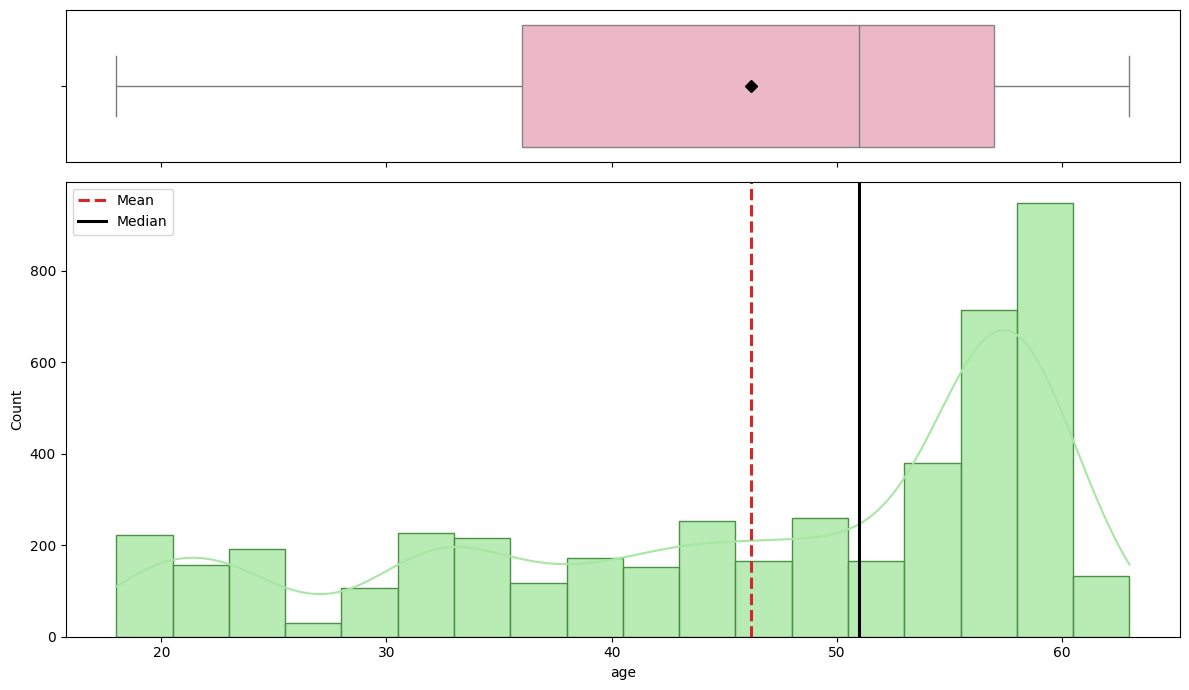

In [18]:
histogram_boxplot(data, 'age', kde=True, bins=None)

**Observations**
- Most of the observations are between 55 and 60 years old.
- The mean age is 46 and the median is 51.
- The distribution shows a slight left skew, meaning there are more people in the older age group and fewer in the younger one.
- The data is concentrated around middle to late adulthood, suggesting that most leads are mid-career professionals.

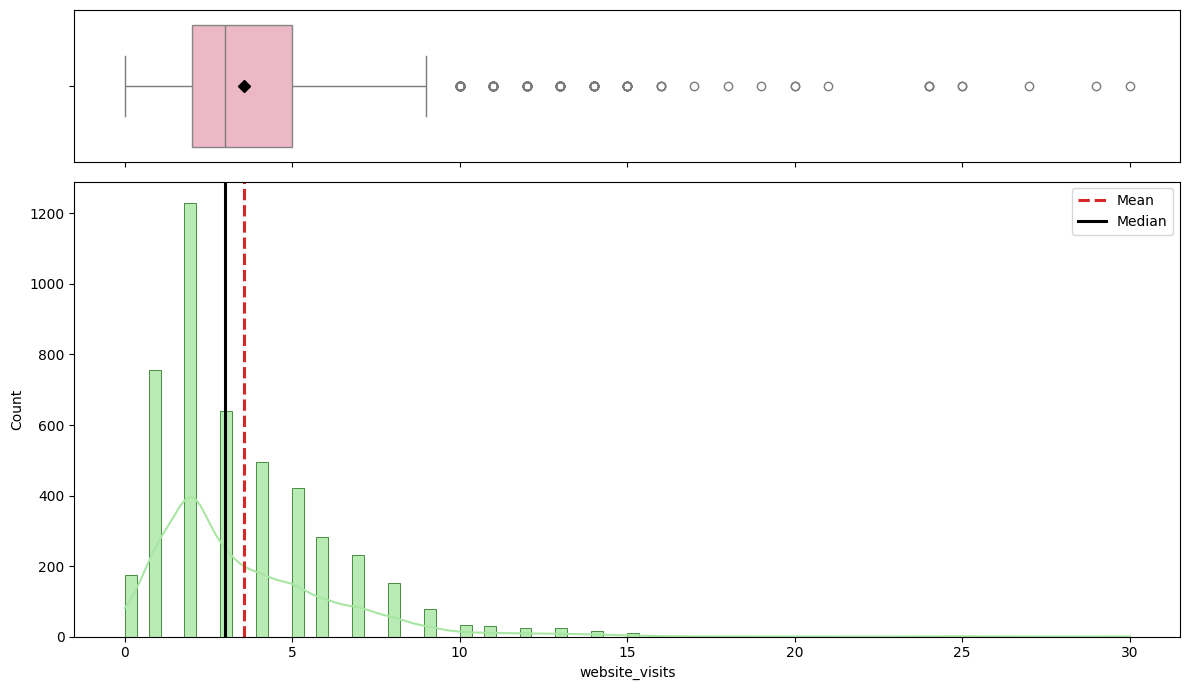

In [19]:
histogram_boxplot(data, 'website_visits', kde=True, bins=None)

**Observations**
- Most of the observations are between 0 and 5 website visits.
- The mean number of visits is around 3.6, while the median is 3.
- The distribution is right-skewed, meaning that most leads visit the website only a few times, while a smaller group visits it many times.
- There are also some outliers with a very high number of visits (above 15 to 30), but these are rare cases.


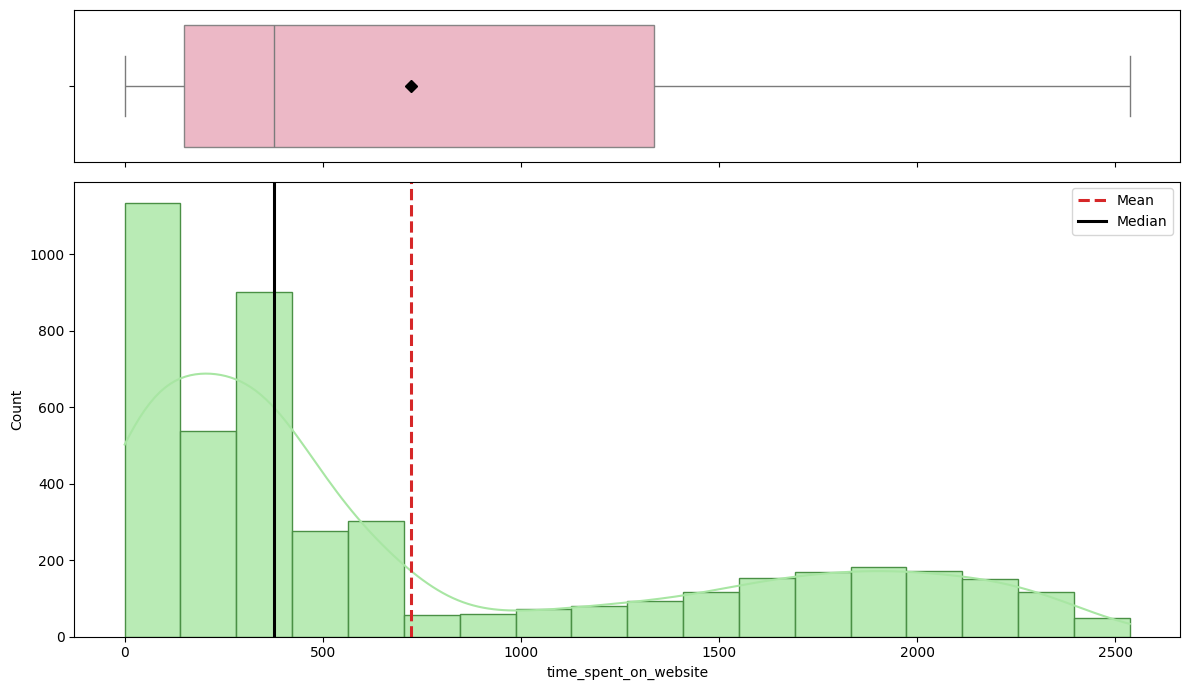

In [20]:
histogram_boxplot(data, 'time_spent_on_website', kde=True, bins=None)

**Observations**
- Most of the observations are concentrated below 500 seconds, meaning that most leads spend less than 8 minutes on the website.
- The mean time spent is around 724 seconds, while the median is 376 seconds.
- The mean is clearly higher than the median, showing a right-skewed distribution — a few leads spend a very long time on the website, pulling the mean upward.
- There are several outliers above 1,500 seconds (25 minutes or more), which represent users who spend an unusually long time browsing the site.
- This pattern suggests that while most users visit briefly, a small group engages deeply with the content. These could be the most interested leads.

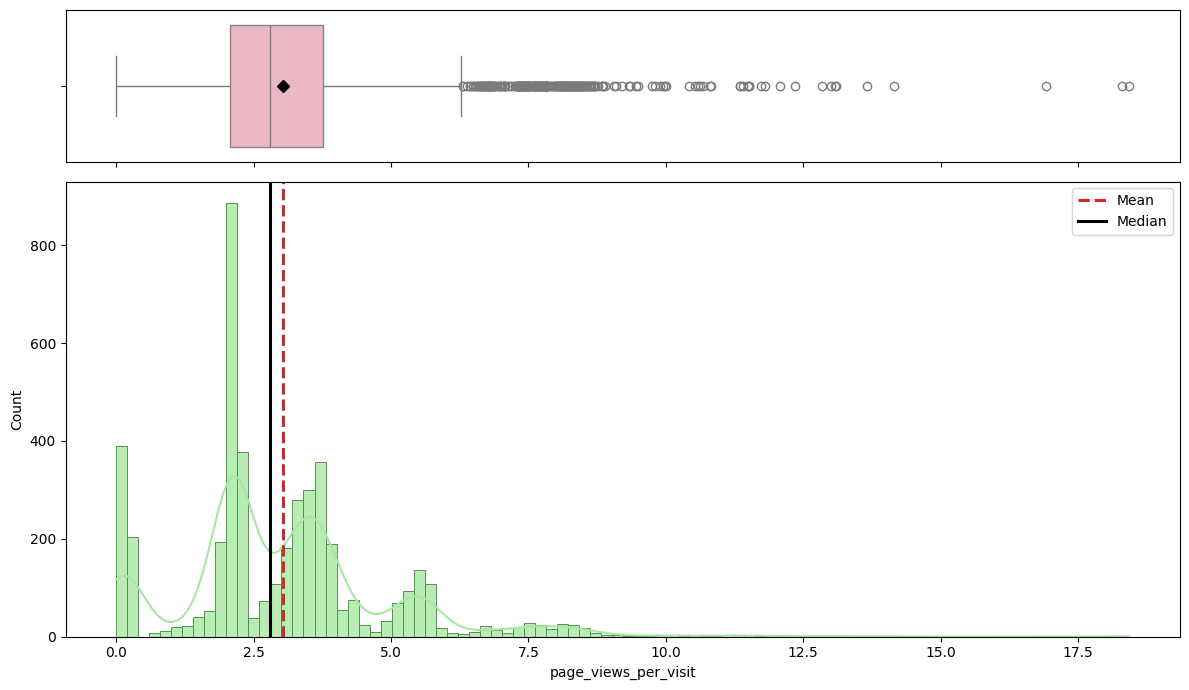

In [21]:
histogram_boxplot(data, 'page_views_per_visit', kde=True, bins=None)

**Observations**
- Most of the observations are concentrated between 2 and 4 page views per visit.
- The mean is around 3, while the median is slightly below 3.
- The distribution is right-skewed, meaning that most leads view only a few pages during each visit, while a small group browses many more pages.
- There are several outliers above 10 page views per visit, representing users who explore the site extensively.
- This pattern suggests that most visitors have short sessions, but a small number of highly engaged users spend more time exploring the platform.

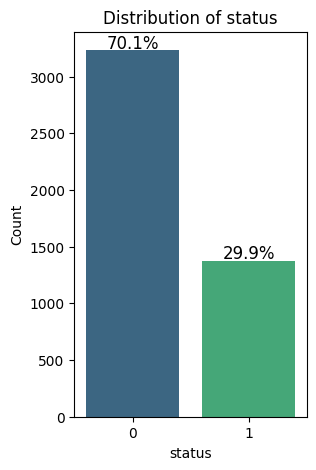

In [22]:
labeled_barplot_desc(data, 'status', perc=True, n=None)

**Observations**
- Around 70% of the leads did not convert to paid customers (status = 0), while about 30% did (status = 1).
- This shows that the dataset is imbalanced, with many more non-converted leads than converted ones.
- The converted leads (status = 1) are the ones the company is most interested in identifying and understanding, since they represent potential customers who successfully completed the conversion process.

#### Categorical Variable

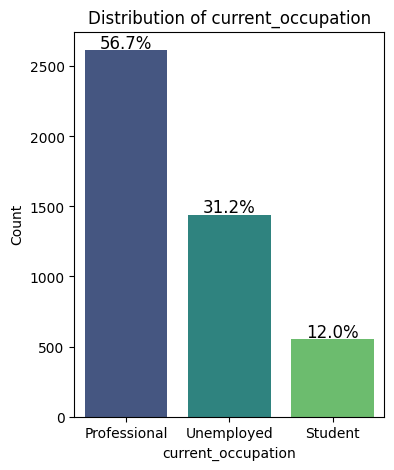

In [23]:
labeled_barplot_desc(data, 'current_occupation', perc=True, n=None)

**Observations**
- As seen in the overview, the majority of the leads are Professionals (56.7%), followed by Unemployed (31.2%) and Students (12%).
- This indicates that most of the potential customers come from a professional background, likely with higher purchasing power and clearer career goals.
- The student group is the smallest segment, which may reflect limited awareness or financial capacity to enroll in paid courses.


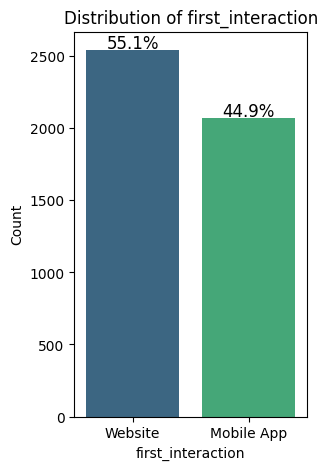

In [24]:
labeled_barplot_desc(data, 'first_interaction', perc=True, n=None)

**Observations**
- Most of the leads first interacted through the Website (55.1%), while 44.9% used the Mobile App.
- This means the Website is the primary entry point for potential customers, but the Mobile App also plays a significant role.
- The difference between both channels is not too large, suggesting that both platforms are important for attracting leads.

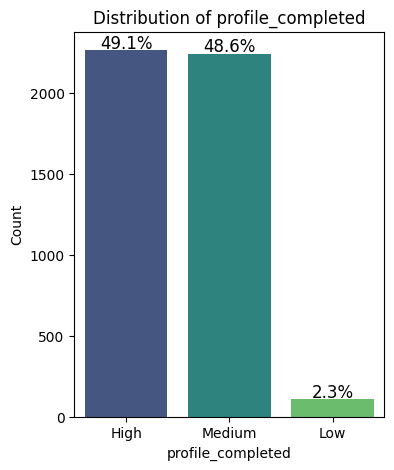

In [25]:
labeled_barplot_desc(data, 'profile_completed', perc=True, n=None)

**Observations**
= Most of the leads have their profiles Highly (49.1%) or Moderately (48.6%) completed.
- Only 2.3% of the leads have a Low level of profile completion.
- This indicates that almost all users share a considerable amount of personal information when signing up, which could mean they are more engaged or curious about the platform.
- Leads with a high completion level might be more serious about the course and therefore more likely to convert.

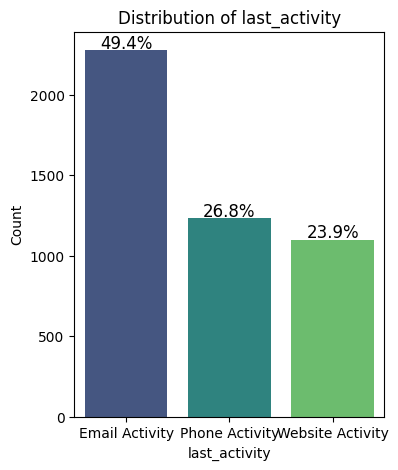

In [26]:
labeled_barplot_desc(data, 'last_activity', perc=True, n=None)

**Observations**
- Almost half of the leads (49.4%) had their last interaction through Email Activity, making it the most common final touchpoint.
- Phone Activity (26.8%) and Website Activity (23.9%) represent smaller but still significant portions of the interactions.
- This suggests that email is the main communication channel used before conversion, but direct contact through phone or browsing activity also plays an important role.

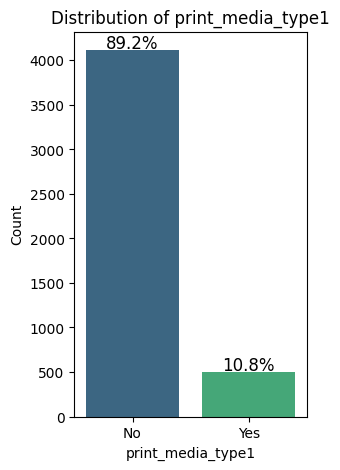

In [27]:
labeled_barplot_desc(data, 'print_media_type1', perc=True, n=None) #Newspaper

**Observations**
- Around 89.2% of the leads have not been reached through newspaper ads, while only 10.8% have.
- This shows that newspapers have limited reach among potential customers.
- As a traditional channel, it seems to generate low awareness or engagement, possibly because most leads discover the program through digital platforms instead.

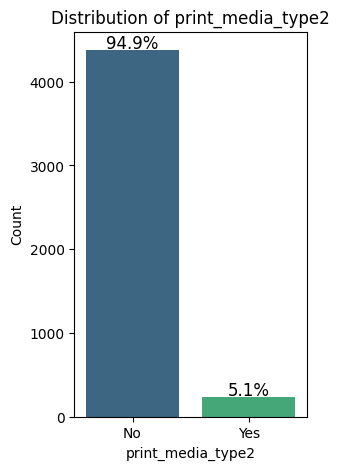

In [28]:
labeled_barplot_desc(data, 'print_media_type2', perc=True, n=None) #Magazine

**Observations**
- Nearly 95% of the leads have not seen the advertisement in magazines, and only 5.1% have.
- This indicates that magazine advertising has an even smaller impact than newspapers.
- Given its low reach, it might target a very specific audience segment, but it does not appear to be an effective channel for attracting large numbers of leads.


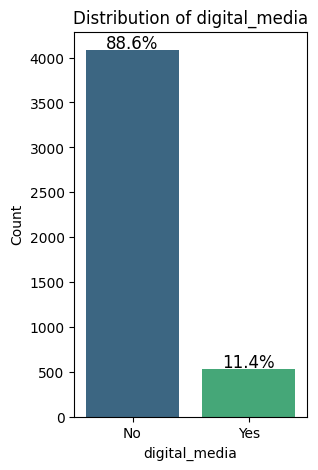

In [29]:
labeled_barplot_desc(data, 'digital_media', perc=True, n=None)

**Observations**
- Around 88.6% of the leads have not interacted with digital media campaigns, while only 11.4% have.
- Despite the lower exposure compared to offline channels like newspapers or magazines, digital media tends to generate higher engagement and can reach users more efficiently through online targeting.
- This pattern suggests that the organization may be underutilizing digital advertising, which could represent a strategic opportunity to attract a broader and more relevant audience segment.


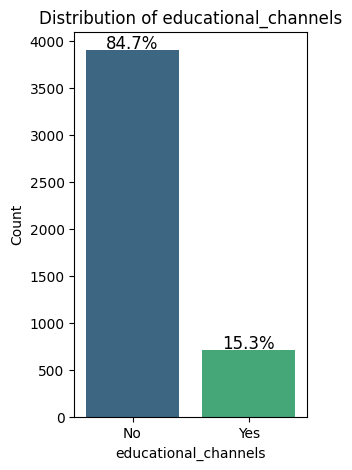

In [30]:
labeled_barplot_desc(data, 'educational_channels', perc=True, n=None)

**Observations**
- Around 84.7% of the leads have not been reached through educational channels, while 15.3% have.
- Although this proportion is relatively small, educational partnerships (like workshops, university collaborations, or online courses) tend to bring in high-quality leads who are genuinely interested in learning.
- This channel might not generate a high volume of leads, but it could improve conversion rates due to the stronger alignment between the course content and the audience's expectations


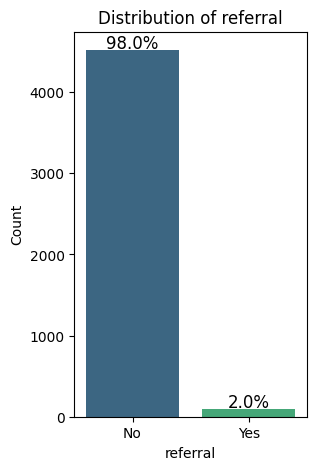

In [31]:
labeled_barplot_desc(data, 'referral', perc=True, n=None)

**Observations**
- A very small percentage of leads (2.0%) come from referrals, while the remaining 98.0% did not.
- This indicates that word-of-mouth marketing is almost nonexistent in this dataset.
- Although referrals currently represent a minor acquisition source, they typically generate highly qualified leads since they come from trusted recommendations.
- Strengthening a referral program could therefore increase both lead quality and conversion rates with relatively low marketing cost.


### Bivariate Analysis

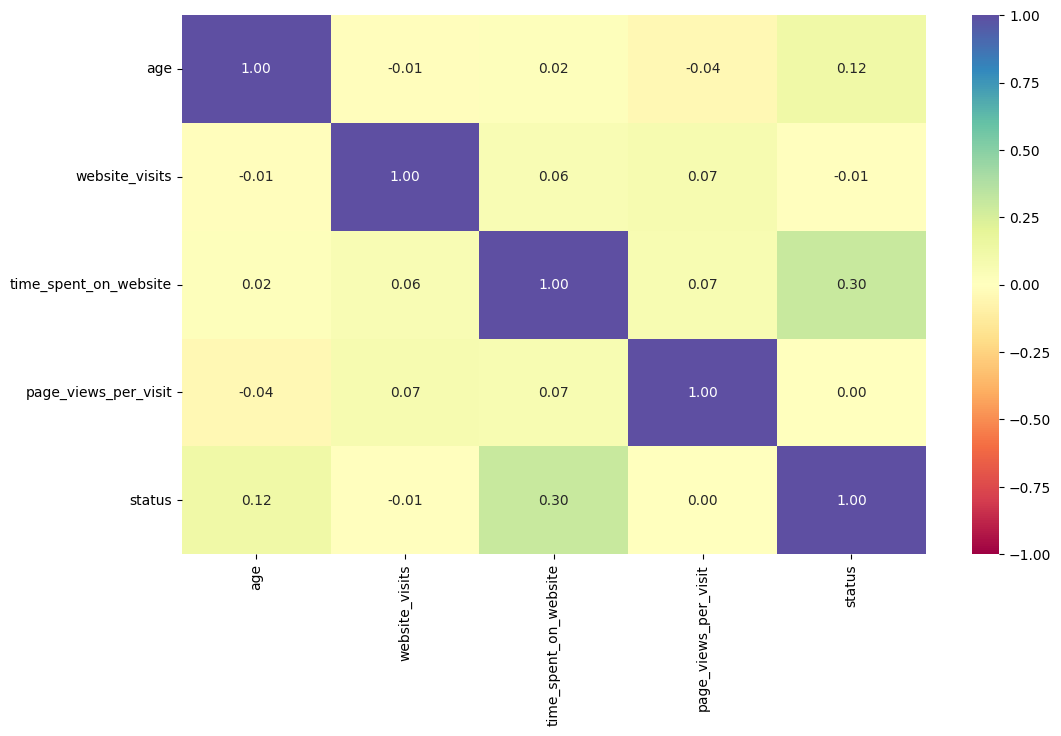

In [32]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 7))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

**Observations**
- There are no highly correlated variables in the dataset. However, there is a moderate positive correlation between status (the target variable) and time_spent_on_website, indicating that leads who spend more time on the website are more likely to become paying customers.
- A very weak positive correlation is also observed between status and age, suggesting that slightly older users may have a higher conversion tendency.
- The rest of the variables show almost no correlation with each other, which means that they are independent, reducing the risk of multicollinearity in the model.


## EDA

- It is a good idea to explore the data once again after manipulating it.

### Answering Questions

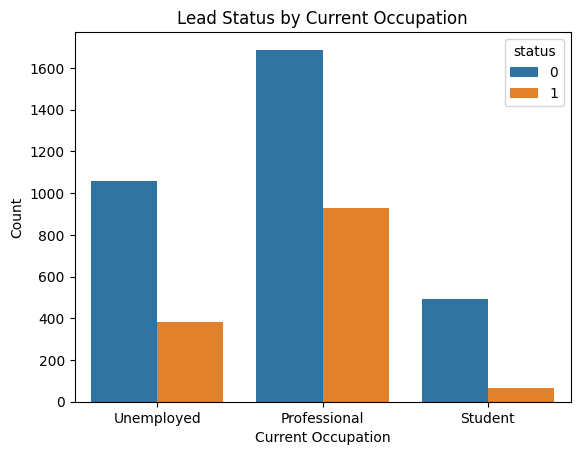

status,0,1
current_occupation,,
Professional,64.487768,35.512232
Student,88.288288,11.711712
Unemployed,73.421235,26.578765


In [33]:
sns.countplot(data=data, x='current_occupation', hue='status')
plt.title('Lead Status by Current Occupation')
plt.xlabel('Current Occupation')
plt.ylabel('Count')
plt.show()

pd.crosstab(data['current_occupation'], data['status'], normalize='index') * 100


**Question 1 - Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.**

- Professionals represent the largest group of leads and also have the highest conversion rate (≈35.5% converted to paid customers).
- Unemployed individuals have a moderate conversion rate (≈26.6%).
- Students show the lowest conversion rate (≈11.7%), meaning they are the least likely to become paying customers.

- This pattern suggests that professionals are more motivated or financially capable of enrolling in the program, while students might be exploring options but less ready to commit financially.
- The company could focus its marketing and follow-up efforts on professionals, as they have a higher likelihood of conversion, or design special offers or student discounts to increase conversions among younger audiences.

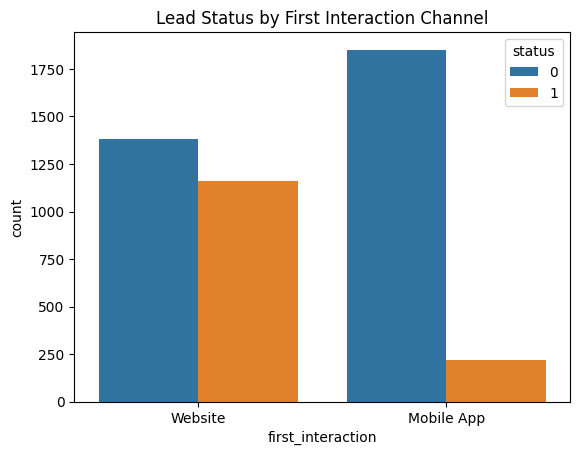

status,0,1
first_interaction,,
Mobile App,89.468599,10.531401
Website,54.405980,45.594020


In [34]:
sns.countplot(data=data, x='first_interaction', hue='status')
plt.title('Lead Status by First Interaction Channel')
plt.show()

pd.crosstab(data['first_interaction'], data['status'], normalize='index') * 100


**Question 2 - The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?**

- Leads whose first interaction was through the website show a conversion rate of 45.6%, which is significantly higher than those who interacted first via the mobile app (only 10.5% conversion).
- Almost 90% of leads from the mobile app did not convert, compared to only 54% of non-conversions from the website channel.

- The website appears to be a much stronger first-touch channel for attracting high-quality leads likely to convert.
- This could indicate that website visitors are more intentional, perhaps browsing with greater interest in course enrollment.
 On the other hand, mobile app users may engage more casually or face usability barriers that reduce conversions.

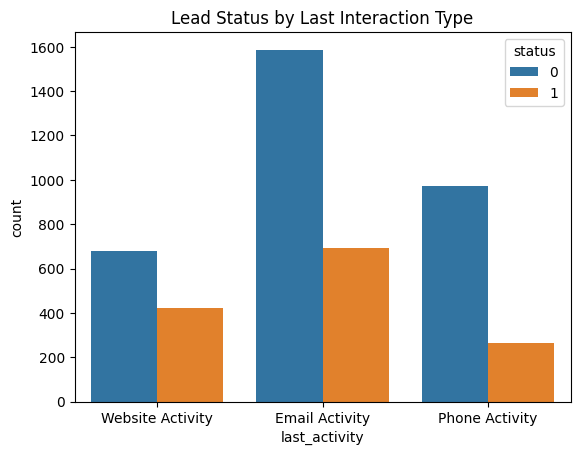

status,0,1
last_activity,,
Email Activity,69.666374,30.333626
Phone Activity,78.687196,21.312804
Website Activity,61.545455,38.454545


In [35]:
sns.countplot(data=data, x='last_activity', hue='status')
plt.title('Lead Status by Last Interaction Type')
plt.show()

pd.crosstab(data['last_activity'], data['status'], normalize='index') * 100


**Question 3 - The company uses multiple modes to interact with prospects. Which way of interaction works best?**

- Leads whose last activity was on the website have the highest conversion rate (≈38.5%), followed by email activity (≈30.3%), and lastly phone activity (≈21.3%).
- Non-conversion rates are higher for email (≈69.7%) and phone (≈78.7%) interactions, suggesting that while these channels reach many leads, they are not as effective in finalizing conversions.

- Website interactions seem to be the most effective at driving conversions, likely because leads engaging directly through the website are taking action on their own initiative (self-motivated users).
- Email and phone activities may indicate follow-up efforts with colder leads,  those less likely to commit.


Conversion rate by print_media_type1:
status                     0          1
print_media_type1                      
No                 70.400972  29.599028
Yes                68.008048  31.991952


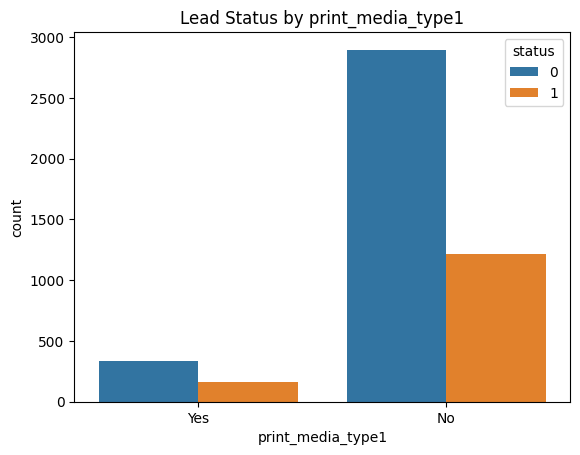


Conversion rate by print_media_type2:
status                     0          1
print_media_type2                      
No                 70.267184  29.732816
Yes                67.811159  32.188841


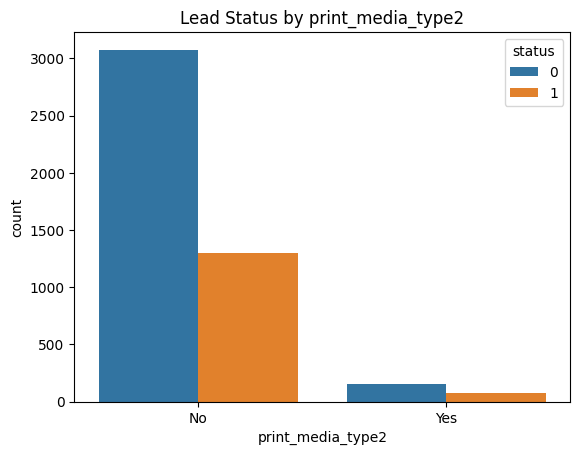


Conversion rate by digital_media:
status                 0          1
digital_media                      
No             70.403917  29.596083
Yes            68.121442  31.878558


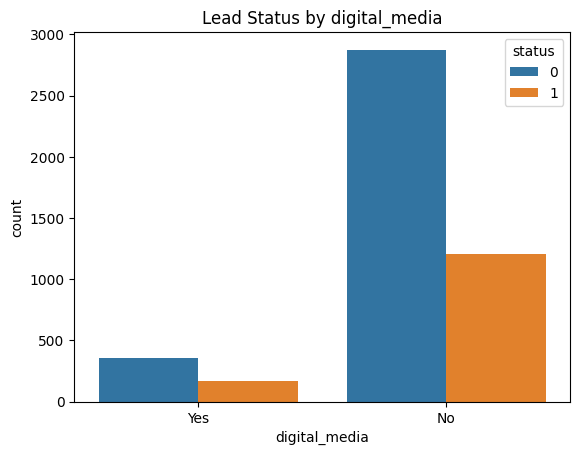


Conversion rate by educational_channels:
status                        0          1
educational_channels                      
No                    69.797799  30.202201
Yes                   72.056738  27.943262


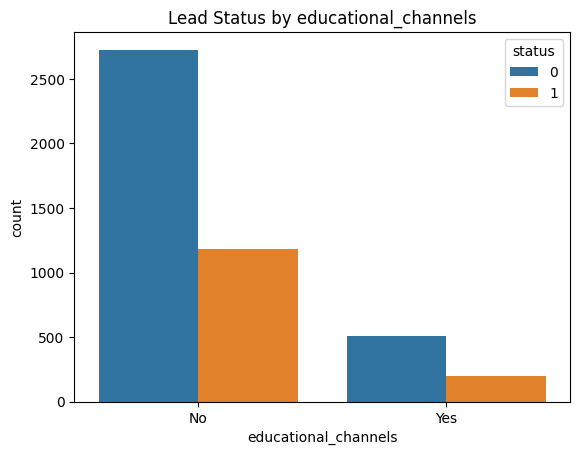


Conversion rate by referral:
status            0          1
referral                      
No        70.922771  29.077229
Yes       32.258065  67.741935


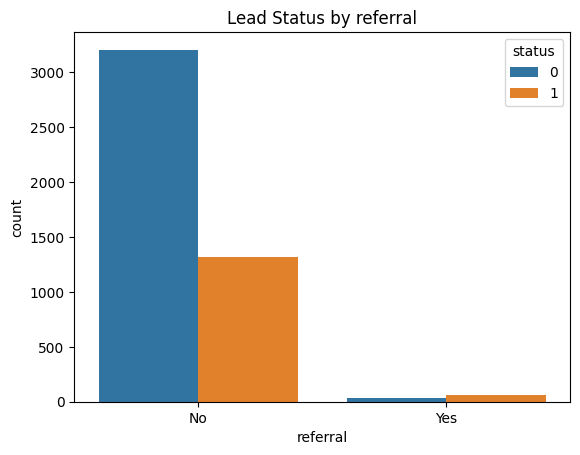

In [36]:
channels = ['print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']
for col in channels:
    print(f"\nConversion rate by {col}:")
    print(pd.crosstab(data[col], data['status'], normalize='index') * 100)
    sns.countplot(data=data, x=col, hue='status')
    plt.title(f'Lead Status by {col}')
    plt.show()


**Question 4 - The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?**

- Print Media (Newspaper & Magazine):

Both print_media_type1 (newspaper) and print_media_type2 (magazine) show similar conversion rates around 31-32%, slightly higher than the overall average (~30%). However, print channels represent a small portion of total leads, so their absolute impact is limited.

- Digital Media:

Leads from digital channels convert at ≈31.9%, almost identical to print. This indicates digital marketing performs equally well but likely reaches more people at lower cost — making it a more scalable option.

- Educational Channels:

These have a slightly lower conversion rate (≈27.9%), suggesting they are less effective in generating qualified leads.

- Referrals:

Although referrals represent a tiny fraction of total leads (≈2%), they show the highest conversion rate by far (≈67.7%).
This means referrals are highly valuable, high-quality leads, even if rare.


-- Referrals are the most effective channel for conversions, users coming from personal recommendations are far more likely to enroll.
-- Digital and print media perform similarly and can complement each other for broader outreach.
-- Educational channels may raise awareness but are less successful in converting interest into action.

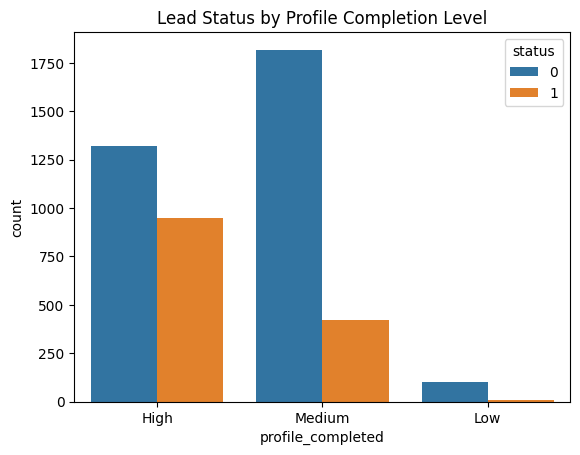

status,0,1
profile_completed,,
High,58.215548,41.784452
Low,92.523364,7.476636
Medium,81.124498,18.875502


In [37]:
sns.countplot(data=data, x='profile_completed', hue='status')
plt.title('Lead Status by Profile Completion Level')
plt.show()

pd.crosstab(data['profile_completed'], data['status'], normalize='index') * 100


**Question 5 - People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?**

- Leads with a highly completed profile have the highest conversion rate (≈41.8%), while those with a medium level convert only ≈18.9%, and those with a low completion level just ≈7.5%.
- Non-conversion rates increase sharply as the level of profile completion decreases — from 58% (High) to 81% (Medium) and up to 92% (Low).

- The trend is clear, the more complete a lead's profile is, the higher the probability of conversion.
- This makes intuitive sense, users who take the time to provide more personal information are more engaged and show a stronger intent to enroll.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

**Observations**

- Missing value treatment - As seen in the overview, there are no missing or duplicated values in the dataset, so no imputation or cleaning was required.

- Outlier detection - Some potential outliers were detected in variables such as time_spent_on_website and page_views_per_visit, but they were kept intentionally, as they likely represent highly engaged users rather than data errors.

### Separate features (X) and target variable (y)

In [38]:
X = data.drop('status', axis=1)
y = data['status']

### Identify categorical variables based on data type and Apply one-hot encoding only to categorical variables

In [39]:
cat_cols = X.select_dtypes(include='object').columns

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [40]:
X_encoded.shape, y.shape

((4612, 16), (4612,))

### Split the dataset into training and testing sets

In [41]:
# 'stratify=y' ensures both subsets keep the same class proportion (0/1 ratio)
# This is important because the target variable is imbalanced (~70% not converted, ~30% converted)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

## Building a Decision Tree model

### Train a Decision Tree (baseline model)

In [42]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)



DecisionTreeClassifier(random_state=42)

### Make predictions

In [44]:
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]


### Evaluate the model with key metrics

- Precision - how many predicted "converted" are actually converted
- Recall - how many real converted leads were detected
- F1-score - harmonic mean between precision and recall (best for imbalanced data)
- ROC-AUC - overall separability between the two classes

In [47]:
print("=== Decision Tree (Baseline) ===")
print("Train accuracy:", dt.score(X_train, y_train))
print("Test  accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision (class 1):", precision_score(y_test, y_pred_dt, zero_division=0))
print("Recall    (class 1):", recall_score(y_test, y_pred_dt, zero_division=0))
print("F1-score  (class 1):", f1_score(y_test, y_pred_dt, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))

print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, digits=3))

=== Decision Tree (Baseline) ===
Train accuracy: 0.9996902106567535
Test  accuracy: 0.8027456647398844
Precision (class 1): 0.6528384279475983
Recall    (class 1): 0.7239709443099274
F1-score  (class 1): 0.6865671641791045
ROC-AUC: 0.7811235265807697

Classification Report:
               precision    recall  f1-score   support

           0      0.877     0.836     0.856       971
           1      0.653     0.724     0.687       413

    accuracy                          0.803      1384
   macro avg      0.765     0.780     0.771      1384
weighted avg      0.810     0.803     0.806      1384



**Observations - Model evaluation results**

- The Decision Tree fits almost perfectly on the training set (99.9% accuracy), which indicates possible overfitting — the model memorized training examples instead of learning general patterns.
- However, the test accuracy drops to ~80%, showing that it performs reasonably well on unseen data but not as strongly as on training data.

- Precision (0.65) means that when the model predicts a lead will convert, it's correct about 65% of the time. There are still some false positives.
- Recall (0.72) means that the model successfully identifies about 72% of all actual converted leads. This is a good recall, which is important when we don't want to miss potential customers.
- The F1-score (0.69) is a balance between precision and recall, giving an overall sense of performance on the positive class (converted leads).
 - ROC-AUC (0.78) shows moderate discriminative power — the model can distinguish between converted and non-converted leads fairly well but has room for improvement.


### Plot Confusion Matrix (Tests set)

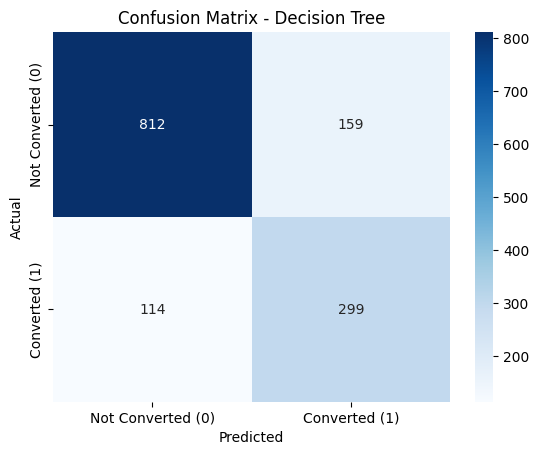

In [49]:
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Converted (0)', 'Converted (1)'],
            yticklabels=['Not Converted (0)', 'Converted (1)'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Observations**
 - 812 (True Negatives) - These leads were not converted, and the model correctly predicted them as not converted.
- 299 (True Positives) - These leads actually converted, and the model predicted converted correctly.

- 159 (False Positives) - These leads did not convert, but the model incorrectly predicted converted (false alarms).
- 114 (False Negatives) - These leads did convert, but the model predicted not converted (missed conversions).

### Visualize the Decision Tree (Baseline)

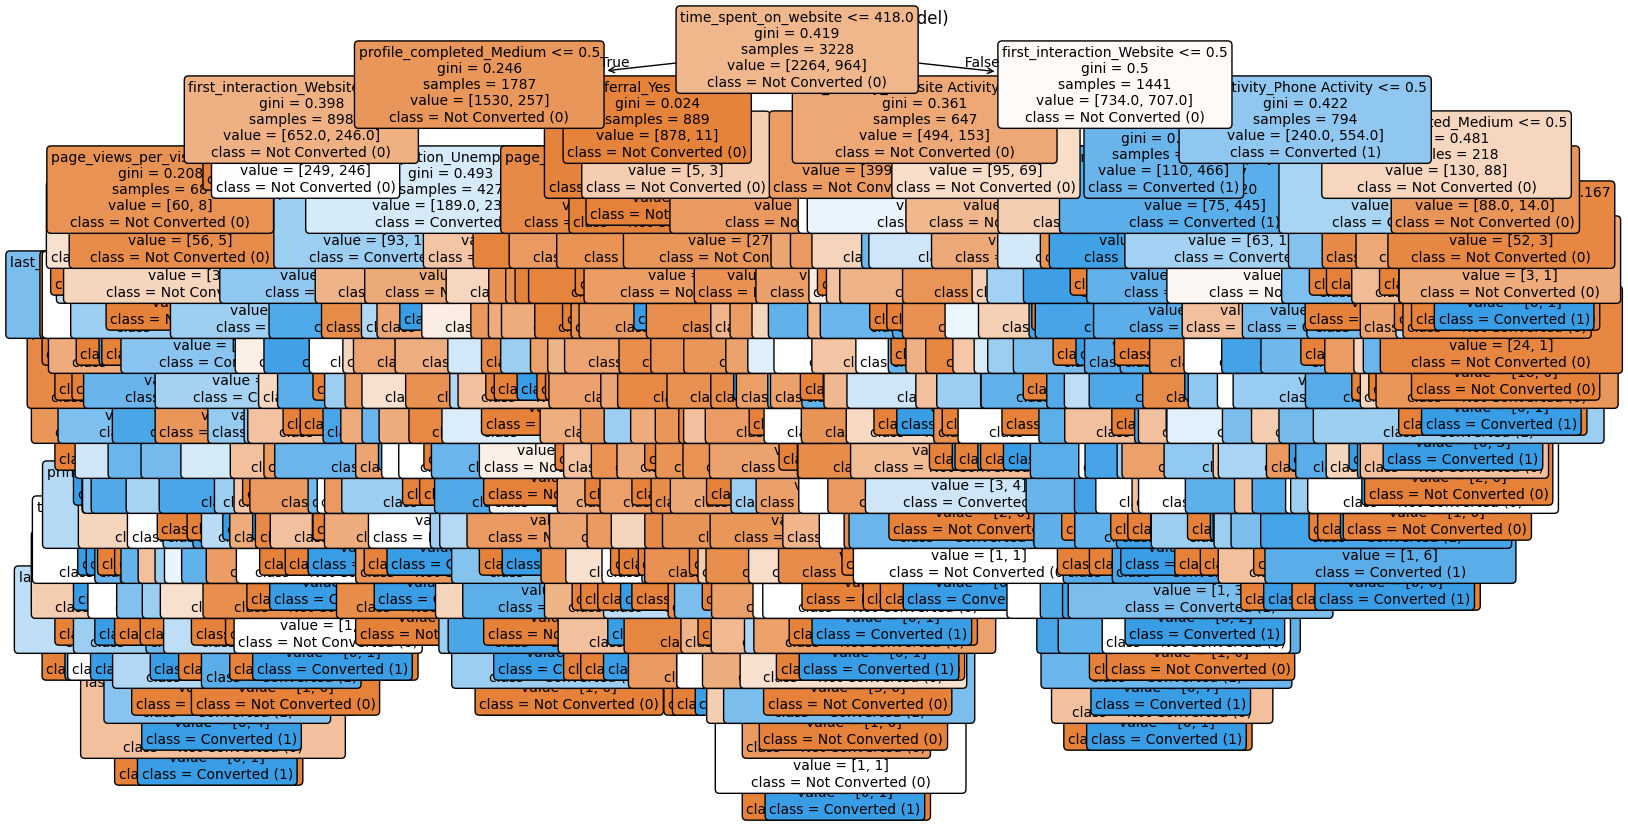

In [58]:
# Increase figure size to make the tree readable
plt.figure(figsize=(18, 10))

# Plot the tree
plot_tree(
    dt,
    feature_names=X_encoded.columns,      # column names (after encoding)
    class_names=['Not Converted (0)', 'Converted (1)'],  # target classes
    filled=True,                  # fill nodes with color according to class
    rounded=True,                 # rounded boxes for cleaner visualization
    fontsize=10                   # text size
)

# Title for clarity
plt.title("Decision Tree (Baseline Model)")
plt.show()

### Importance of features in the tree building

In [59]:
print (pd.DataFrame(dt.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                     Imp
time_spent_on_website           0.253166
first_interaction_Website       0.195878
page_views_per_visit            0.136316
age                             0.103656
profile_completed_Medium        0.083282
website_visits                  0.046592
last_activity_Phone Activity    0.046216
current_occupation_Unemployed   0.039451
last_activity_Website Activity  0.022232
profile_completed_Low           0.018149
digital_media_Yes               0.012580
print_media_type1_Yes           0.011103
current_occupation_Student      0.009096
referral_Yes                    0.008222
educational_channels_Yes        0.007598
print_media_type2_Yes           0.006463


### Plotting the feature importance

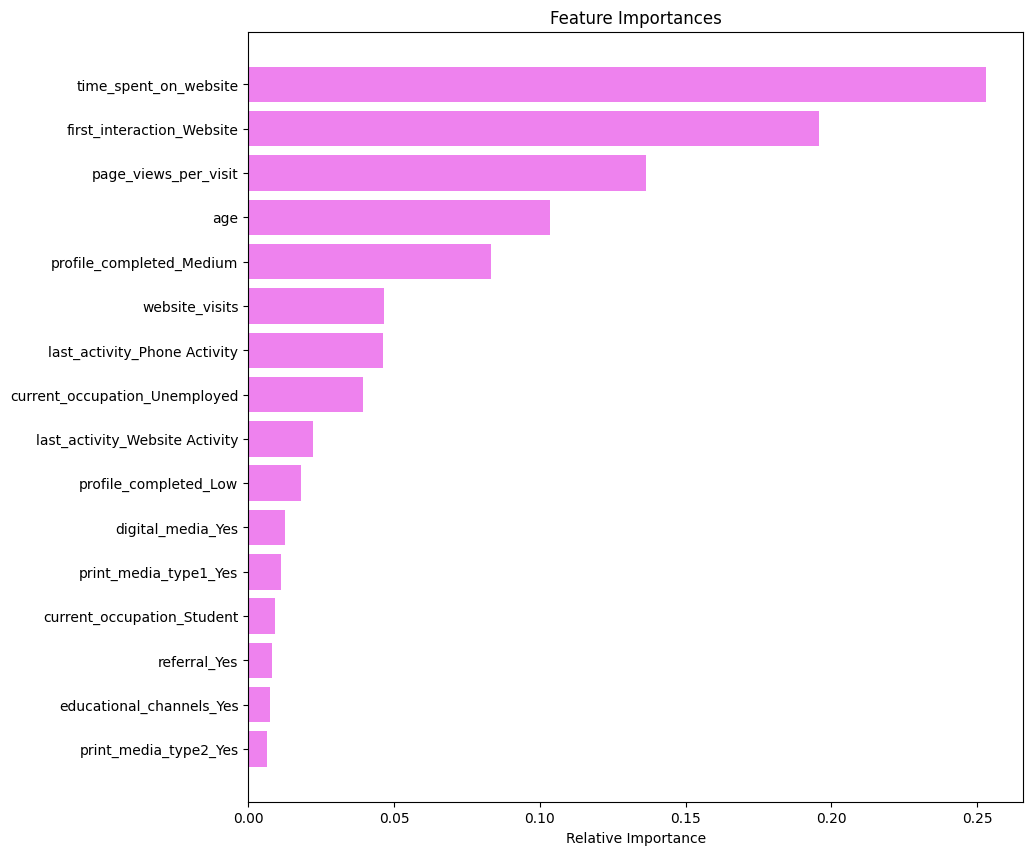

In [60]:

importances = dt.feature_importances_

indices = np.argsort(importances)

plt.figure(figsize = (10, 10))

plt.title('Feature Importances')

plt.barh(range(len(indices)), importances[indices], color = 'violet', align = 'center')

plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])

plt.xlabel('Relative Importance')

plt.show()

**Observations - Feature Importance for Decision Tree**

The feature_importances_ attribute shows the relative importance of each feature based on how much it reduces impurity (Gini or entropy) across the tree.

time_spent_on_website is by far the most important predictor of conversion, leads who spend more time on the website tend to convert more often.

This is followed by first_interaction_Website and page_views_per_visit, which are also strong predictors, suggesting that digital engagement through website interactions plays a key role in lead conversion.

Additionally, age and profile_completed_Medium have a notable influence, likely indicating that older users or those with more complete profiles are more inclined to enroll.

Finally, other variables such as print_media, referral, and educational_channels show very low importance, meaning they contribute minimally to the model's predictions.

## Do we need to prune the tree?

The Decision Tree is definitely overfitting, because:
- Train accuracy ≈ 100%
- Test accuracy ≈ 80%

The gap (>15%) is too large

So yes, pruning is necessary to make the model more reliable.

By pruning the tree we:
- Simplify the model (less memorization),
- Increase generalization (better accuracy),
- Reduce variance (more stable predictions).

### Decision Tree - Grid Search - Objective: maximize Recall (clase 1)

In [73]:
# Define the base classifier
# 'class_weight' helps the model pay more attention to the minority class (1 ≈ 30%) without needing to oversample. The weights can be adjusted if needed.
d_tree_base = DecisionTreeClassifier(
    random_state=7,
    class_weight={0: 0.3, 1: 0.7})

In [74]:
# Define the hyperparameter search space (acts as "indirect pruning") 'max_depth' and 'min_samples_leaf' control the model complexity, reduce overfitting
param_grid = {
    'max_depth': np.arange(2, 10),
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [5, 10, 20, 25]
}

In [75]:
# Define the scoring metric: Recall for the positive class (1, Prioritize detecting converted leads (minimize false negatives)
recall_scorer = metrics.make_scorer(recall_score, pos_label=1)

In [76]:
# Run GridSearchCV with 5-fold cross-validation, It will test all parameter combinations and select the one with the highest recall
grid = GridSearchCV(
    estimator=d_tree_base,
    param_grid=param_grid,
    scoring=recall_scorer,
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

In [77]:
# Fit the grid search
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV recall (class 1):", grid.best_score_)

Best params: {'criterion': 'gini', 'max_depth': np.int64(3), 'min_samples_leaf': 5}
Best CV recall (class 1): 0.9004317789291882


In [78]:
# Extract and retrain the best model, GridSearchCV already fits the best estimator, but we reassign it for clarity
d_tree_tuned = grid.best_estimator_
d_tree_tuned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, max_depth=np.int64(3),
                       min_samples_leaf=5, random_state=7)

In [79]:
# Evaluate the model on both Train and Test sets
y_pred_tr = d_tree_tuned.predict(X_train)
y_pred_te = d_tree_tuned.predict(X_test)

y_proba_tr = d_tree_tuned.predict_proba(X_train)[:, 1]
y_proba_te = d_tree_tuned.predict_proba(X_test)[:, 1]

### Decision Tree Pruned (Tuned)

In [81]:
print("=== Decision Tree Pruned ===")
print("Train accuracy:", d_tree_tuned.score(X_train, y_train))
print("Test  accuracy:", accuracy_score(y_test, y_pred_te))
print("Precision (class 1):", precision_score(y_test, y_pred_te, zero_division=0))
print("Recall    (class 1):", recall_score(y_test, y_pred_te, zero_division=0))
print("F1-score  (class 1):", f1_score(y_test, y_pred_te, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_te))

print("\nClassification Report:\n", classification_report(y_test, y_pred_te, digits=3))


=== Decision Tree (Pruned / Tuned) ===
Train accuracy: 0.7896530359355638
Test  accuracy: 0.7890173410404624
Precision (class 1): 0.5971107544141252
Recall    (class 1): 0.9007263922518159
F1-score  (class 1): 0.7181467181467182
ROC-AUC: 0.8787326412699521

Classification Report:
               precision    recall  f1-score   support

           0      0.946     0.742     0.831       971
           1      0.597     0.901     0.718       413

    accuracy                          0.789      1384
   macro avg      0.772     0.821     0.775      1384
weighted avg      0.842     0.789     0.798      1384



**Observations**

- Train Accuracy: 0.79
- Test Accuracy: 0.79 - Indicates that the model no longer overfits (train and test are very close).
- Precision (class 1 = converted): 0.60 - Around 60% of the leads predicted as converted actually convert.
- The model makes some false positives, but that's acceptable when the goal is to not miss potential converters.
- Recall (class 1): 0.90 - The model successfully identifies about 90% of all real conversions, excellent sensitivity. This is the main metric optimized, and it worked well.
- F1-score (class 1): 0.72 - Balanced performance between precision and recall.
- ROC-AUC: 0.88 - Strong overall separability between the two classes.

### Plot Confusion Matrix (Tests set) - Pruned (Tuned) Decision Tree

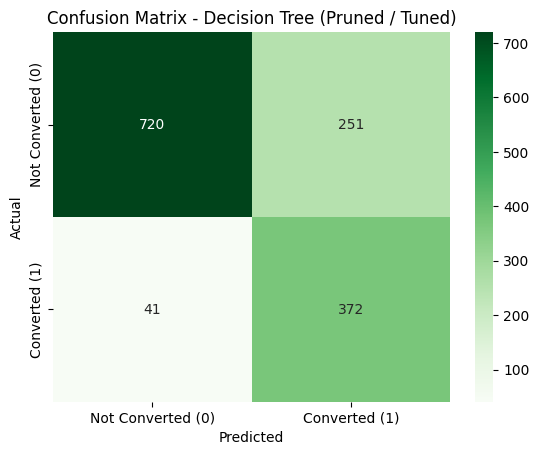

In [89]:
cm = confusion_matrix(y_test, y_pred_te)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Converted (0)', 'Converted (1)'],
            yticklabels=['Not Converted (0)', 'Converted (1)'])

plt.title('Confusion Matrix - Decision Tree Pruned')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


**Observations**

- True Negatives (720) - Leads that did not convert and were correctly predicted as not converted.
- False Positives (251) - Leads that did not convert but were incorrectly predicted as converted.
- False Negatives (41): Leads that converted but were predicted as not converted. Relatively low, which aligns with the model's high recall (0.90).
- True Positives (372)- Leads that converted and were correctly predicted as converted.

### Visualize the Decision Tree Pruned (Tuned)

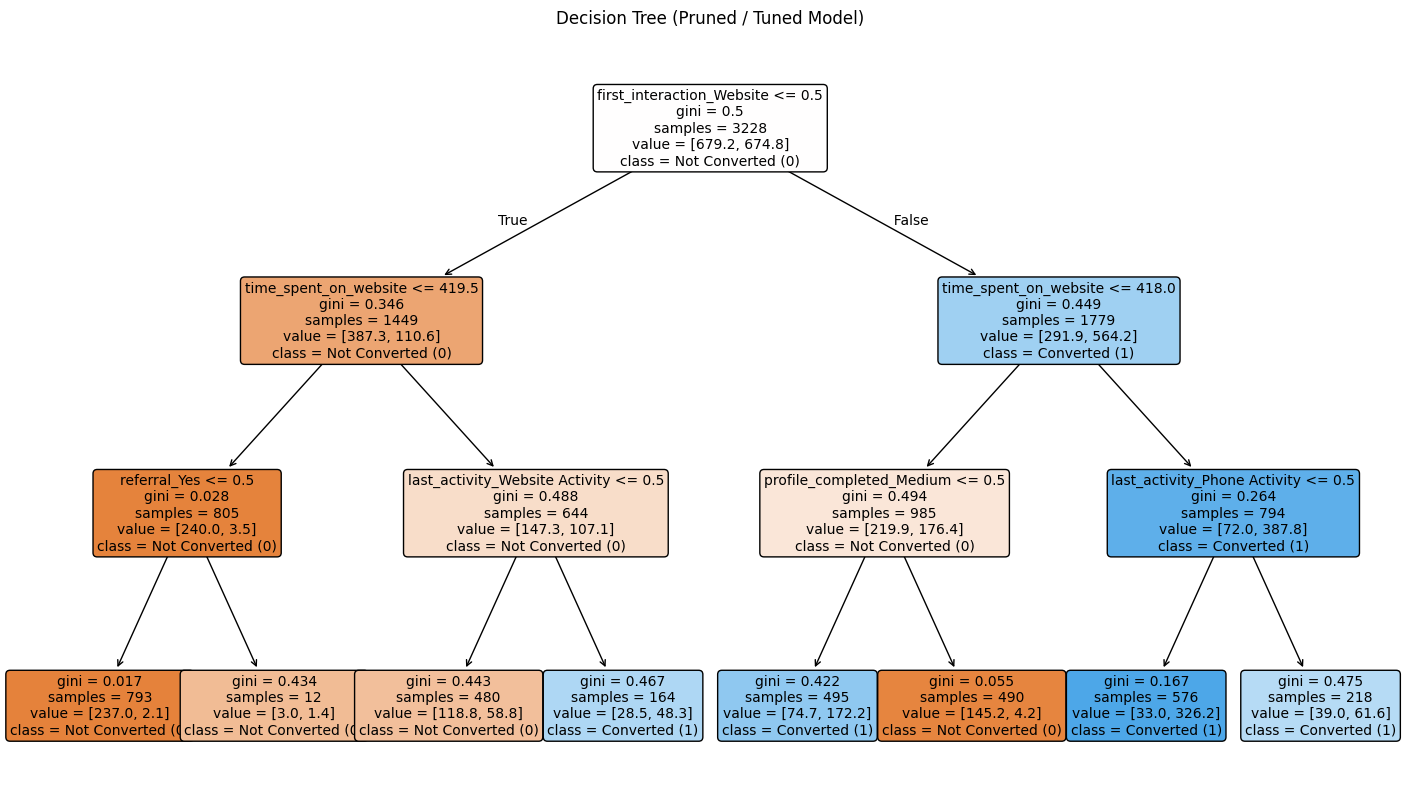

In [84]:
# Visualize the Pruned (Tuned) Decision Tree
# Increase figure size so the tree is readable
plt.figure(figsize=(18, 10))

# Plot the pruned (tuned) decision tree
plot_tree(
    d_tree_tuned,                        # the tuned model
    feature_names=X_train.columns,       # feature names after encoding
    class_names=['Not Converted (0)', 'Converted (1)'],  # target class labels
    filled=True,                         # fill nodes with colors by class
    rounded=True,                        # rounded boxes for cleaner visuals
    fontsize=10,                         # readable font size
    max_depth=4                          # only show top 4 levels for readability
)

# Add a title for clarity
plt.title("Decision Tree Pruned Model")
plt.show()


### Importance of features for the Pruned (Tuned) Decision Tree

In [88]:
print(
    pd.DataFrame(
        d_tree_tuned.feature_importances_,   # importance values from the tuned model
        columns=["Importance"],              # column label
        index=X_train.columns                # feature names
    ).sort_values(by="Importance", ascending=False)
)



                                Importance
first_interaction_Website         0.357321
time_spent_on_website             0.323095
profile_completed_Medium          0.247958
last_activity_Phone Activity      0.040890
last_activity_Website Activity    0.028278
referral_Yes                      0.002459
website_visits                    0.000000
age                               0.000000
profile_completed_Low             0.000000
current_occupation_Unemployed     0.000000
current_occupation_Student        0.000000
page_views_per_visit              0.000000
print_media_type1_Yes             0.000000
print_media_type2_Yes             0.000000
digital_media_Yes                 0.000000
educational_channels_Yes          0.000000


### Plotting the feature importance Pruned (Tuned) Decision Tree

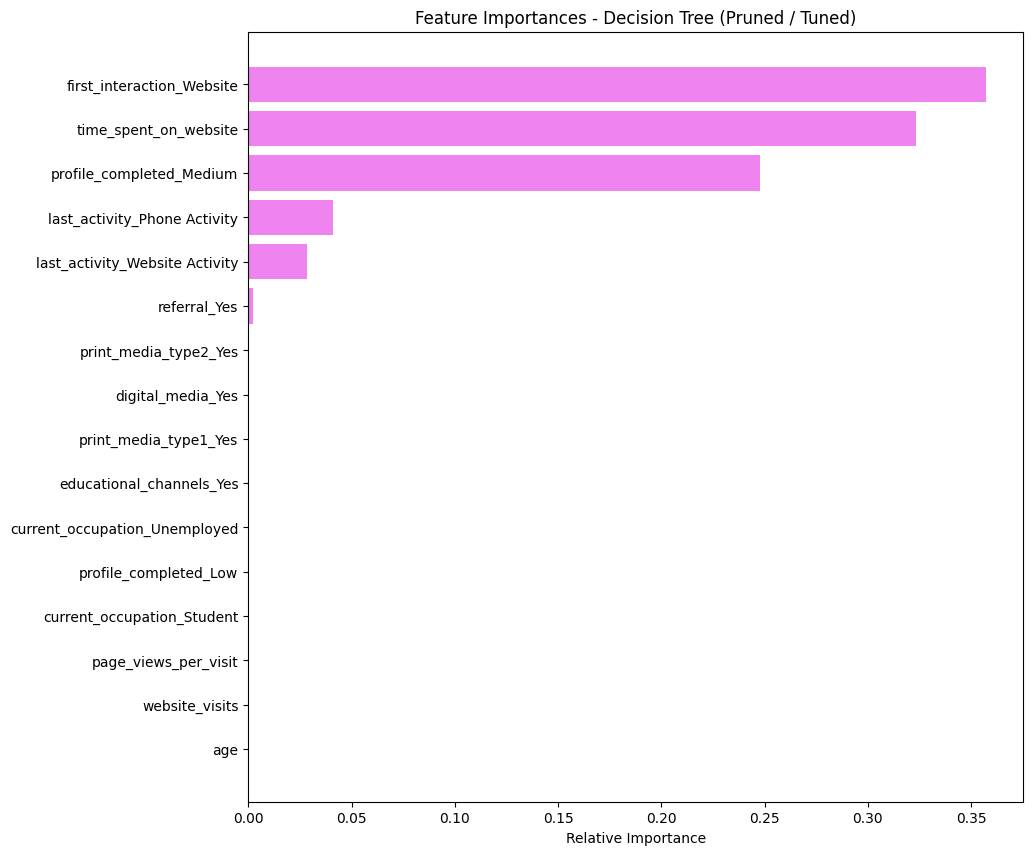

In [86]:
# Extract feature importances from the tuned Decision Tree
importances = d_tree_tuned.feature_importances_

# Sort the feature indices by importance value
indices = np.argsort(importances)

# Create the plot
plt.figure(figsize=(10, 10))
plt.title('Feature Importances - Decision Tree Pruned')

# Horizontal bar chart of importances
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')

# Add feature names on the y-axis
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])

# Label the x-axis
plt.xlabel('Relative Importance')

# Show the plot
plt.show()


**Observations**

- first_interaction_Website and time_spent_on_website are the two most influential variables, confirming that digital engagement is the strongest predictor of conversion. Leads whose first contact was through the website and who spend more time browsing are significantly more likely to convert.
- profile_completed_Medium also has a strong impact, suggesting that users who provide more personal details are more engaged and more likely to enroll.
- last_activity_Phone Activity and last_activity_Website Activity have smaller but still meaningful effects, showing that recent activity (especially phone contact) can influence conversion.
- referral_Yes and all types of media channels (print, digital, educational) have very low importance. This indicates that traditional or indirect channels contribute little to the model's predictive power.

#### Comparing both models

In [92]:
def get_metrics(model, X_train, y_train, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        "Train Accuracy": model.score(X_train, y_train),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Precision (class 1)": precision_score(y_test, y_pred, zero_division=0),
        "Recall (class 1)": recall_score(y_test, y_pred, zero_division=0),
        "F1-score (class 1)": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }


In [93]:
# Get both models’ metrics
baseline_metrics = get_metrics(dt, X_train, y_train, X_test, y_test)
tuned_metrics = get_metrics(d_tree_tuned, X_train, y_train, X_test, y_test)

# Combine into a comparison DataFrame
comparison_df = pd.DataFrame({
    "Metric": list(baseline_metrics.keys()),
    "Decision Tree (Baseline)": list(baseline_metrics.values()),
    "Decision Tree (Pruned/Tuned)": list(tuned_metrics.values())
})

# Display comparison table
print("=== Comparison: Baseline vs Pruned Decision Tree ===")
display(
    comparison_df.style
        .format({"Decision Tree (Baseline)": "{:.3f}", "Decision Tree (Pruned/Tuned)": "{:.3f}"})
        .set_caption("Model Performance Comparison")
        .background_gradient(cmap="Greens", axis=None)
)


=== Comparison: Baseline vs Pruned Decision Tree ===


,Metric,Decision Tree (Baseline),Decision Tree (Pruned/Tuned)
0,Train Accuracy,1.000,0.790
1,Test Accuracy,0.803,0.789
2,Precision (class 1),0.653,0.597
3,Recall (class 1),0.724,0.901
4,F1-score (class 1),0.687,0.718
5,ROC-AUC,0.781,0.879


**Observations**

- After comparing the baseline and pruned Decision Tree model, the tuned version demonstrates a better generalization ability and stronger predictive power for identifying potential conversions.

- The baseline model achieved perfect accuracy on the training set (1.00) but lower accuracy on the test set (0.80), indicating clear overfitting, it memorized the training data instead of learning general patterns.

- The pruned/tuned model shows balanced performance: its training accuracy (0.79) is now close to its test accuracy (0.789), meaning it generalizes much better.

- Recall (class 1) increased substantially (from 0.72 to 0.90), showing that the pruned model identifies a much higher proportion of actual conversions, which is crucial for marketing use cases where missing a potential lead is costly.

- Although precision slightly decreased (from 0.65 to 0.60), the trade-off is acceptable because the overall F1-score (0.69 → 0.72) and ROC-AUC (0.78 → 0.88) improved, confirming better overall classification quality.

So in conclcusion, the Pruned/Tuned Decision Tree outperforms the baseline by reducing overfitting, significantly improving recall and ROC-AUC, and maintaining strong overall accuracy. It is the preferred model for detecting potential customer conversions, as it better balances sensitivity and generalization.

## Building a Random Forest model

### Train a Random Forest model

In [94]:
rf = RandomForestClassifier(
    random_state=7,
    class_weight={0: 0.3, 1: 0.7},  # handle class imbalance
    n_estimators=100,               # number of trees
    max_depth=None,                 # allow trees to grow fully
    n_jobs=-1                       # use all CPU cores
)

# Fit the model
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight={0: 0.3, 1: 0.7}, n_jobs=-1, random_state=7)

### Make predictions

In [95]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]


### Evaluate the model with key metrics

In [96]:
print("=== Random Forest (Baseline) ===")
print("Train accuracy:", rf.score(X_train, y_train))
print("Test  accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision (class 1):", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall    (class 1):", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1-score  (class 1):", f1_score(y_test, y_pred_rf, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, digits=3))


=== Random Forest (Baseline) ===
Train accuracy: 0.9996902106567535
Test  accuracy: 0.851878612716763
Precision (class 1): 0.7751322751322751
Recall    (class 1): 0.7094430992736077
F1-score  (class 1): 0.7408343868520859
ROC-AUC: 0.9111036025365129

Classification Report:
               precision    recall  f1-score   support

           0      0.881     0.912     0.896       971
           1      0.775     0.709     0.741       413

    accuracy                          0.852      1384
   macro avg      0.828     0.811     0.819      1384
weighted avg      0.849     0.852     0.850      1384



**Observations**
 - Train accuracy 0.9997 — almost perfect on the training data, indicating that the model fits the training set extremely well.
- Test accuracy 0.852 — still high on unseen data, suggesting the model generalizes well, though the large gap between train and test accuracy hints at some overfitting, which is common for Random Forests with deep trees.


- Precision (class 1) 0.775 - about 78% of leads predicted as “converted” were actually true conversions.
- Recall (class 1) 0.709 - the model correctly identifies around 71% of all actual conversions.

- F1-score (class 1) 0.741 → harmonic mean of precision and recall, showing a good overall balance.

These values reflect a strong ability to capture true conversions while keeping false positives relatively low, ideal for marketing or customer acquisition settings.


### Plot Confusion Matrix (Tests set)

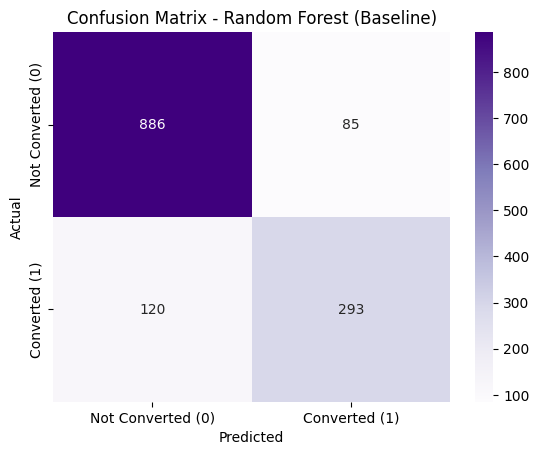

In [97]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Converted (0)', 'Converted (1)'],
            yticklabels=['Not Converted (0)', 'Converted (1)'])
plt.title('Confusion Matrix - Random Forest (Baseline)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


**Observations**

- True Negatives (886) - The model correctly identified 886 leads as not converted.
- True Positives (293) - The model correctly predicted 293 real conversions.
- False Negatives (120) - These are leads that actually converted, but the model missed them (predicted as 0).
- False Positives (85) - Leads predicted as converted, but actually didn't convert.

The Random Forest does a strong job identifying non-converted leads (high precision for class 0),
while also detecting a large portion of the converted leads (recall = 0.71).
There are still some false negatives, meaning a few real conversions are missed, but the overall balance between precision and recall is excellent, consistent with the F1-score of 0.74 and AUC of 0.91 seen earlier.

### Importance of features in the tree building

In [98]:
feature_imp = pd.DataFrame(
    rf.feature_importances_,
    index=X_train.columns,
    columns=["Importance"]
).sort_values(by="Importance", ascending=False)

print("Top 10 Feature Importances (Random Forest):")
print(feature_imp.head(10))


Top 10 Feature Importances (Random Forest):
                                Importance
time_spent_on_website             0.283942
first_interaction_Website         0.186067
page_views_per_visit              0.108875
age                               0.103269
profile_completed_Medium          0.102977
website_visits                    0.063907
last_activity_Phone Activity      0.030538
current_occupation_Unemployed     0.024390
last_activity_Website Activity    0.021265
current_occupation_Student        0.015847


**Observations**

The Random Forest model confirms that digital engagement variables are the most influential in predicting lead conversion.
- Time spent on website and first interaction via website are the strongest predictors, meaning users who explore the site longer and engage online are more likely to convert.
- Other relevant factors include page views per visit, age, and profile completion level, which all positively affect conversion likelihood.
- Traditional or external sources like print media and referrals have minimal influence, suggesting that conversion is mainly driven by online interaction and engagement.

### Plotting the feature importance

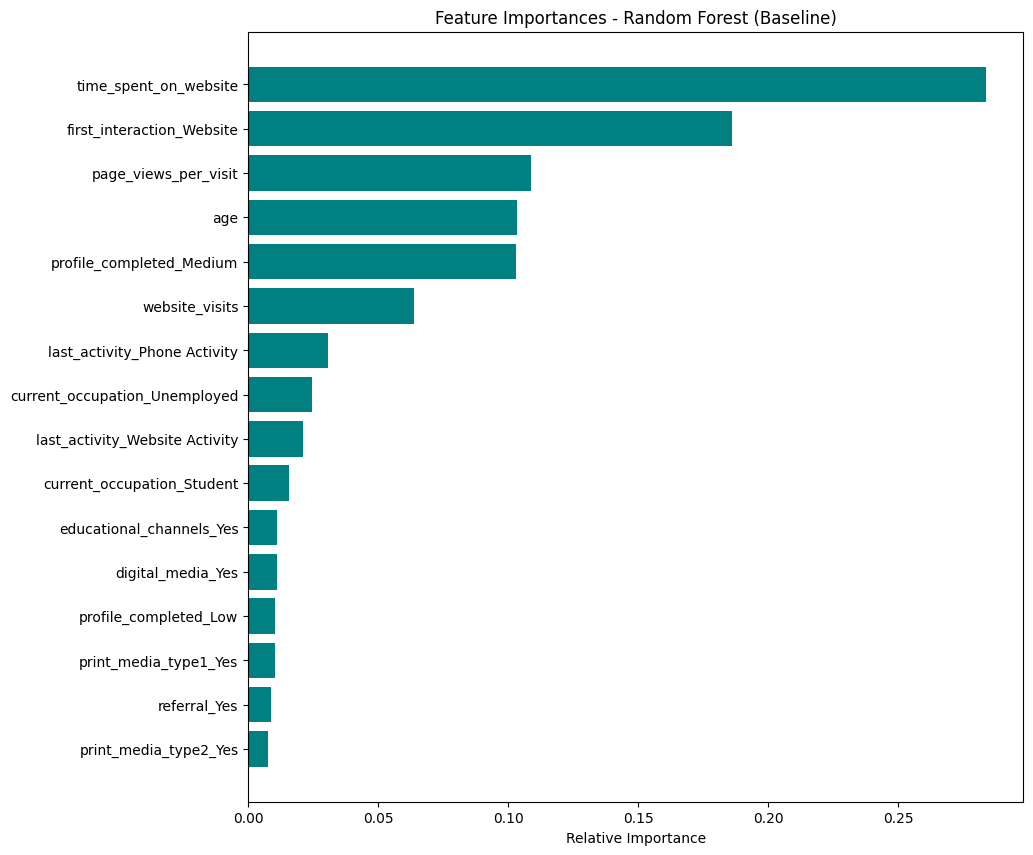

In [99]:
importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 10))
plt.title('Feature Importances - Random Forest (Baseline)')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()


## Do we need to prune the tree?

No, the Random Forest model does not require pruning.

Unlike a single Decision Tree, which can easily overfit the training data, a Random Forest is an ensemble of many trees built on random subsets of data and features. This randomness naturally reduces overfitting by averaging multiple trees' predictions.

Instead of pruning, Random Forests are optimized by tuning hyperparameters, such as:
- n_estimators - number of trees in the forest
- max_depth - maximum depth of each tree
- min_samples_split and min_samples_leaf - control how splits are made
- max_features - limits the number of features considered at each split

### Random Forest - Grid Search

In [100]:
# Define the base estimator for tuning
rf_base = RandomForestClassifier(criterion="entropy", random_state=7)

In [101]:
# Hyperparameter grid (acts as "pruning"/regularization for RF)
param_grid_rf = {
    "n_estimators": [110, 120],
    "max_depth": [6, 7],
    "min_samples_leaf": [20, 25],
    "max_features": [0.8, 0.9],
    "max_samples": [0.9, 1.0],
    "class_weight": ["balanced", {0: 0.3, 1: 0.7}]
}

In [102]:
# Selection metric - Recall on positive class (1)
rf_recall_scorer = metrics.make_scorer(recall_score, pos_label=1)

In [103]:
# GridSearchCV with 5-fold CV
grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring=rf_recall_scorer,
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

In [104]:
# Fit the search
grid_rf.fit(X_train, y_train)
print("Best params (RF):", grid_rf.best_params_)
print("Best CV Recall (class 1):", grid_rf.best_score_)

Best params (RF): {'class_weight': 'balanced', 'max_depth': 6, 'max_features': 0.8, 'max_samples': 0.9, 'min_samples_leaf': 25, 'n_estimators': 120}
Best CV Recall (class 1): 0.8589378238341968


In [105]:
# Best tuned model
rf_tuned = grid_rf.best_estimator_
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=6, max_features=0.8, max_samples=0.9,
                       min_samples_leaf=25, n_estimators=120, random_state=7)

In [106]:
# Predictions & probabilities (Train/Test)
y_pred_rf_tr = rf_tuned.predict(X_train)
y_pred_rf_te = rf_tuned.predict(X_test)

y_proba_rf_tr = rf_tuned.predict_proba(X_train)[:, 1]
y_proba_rf_te = rf_tuned.predict_proba(X_test)[:, 1]

### Random Forest Tuned

In [112]:
print("\n=== Random Forest Tuned ===")
print("Train accuracy:", rf_tuned.score(X_train, y_train))
print("Test  accuracy:", accuracy_score(y_test, y_pred_rf_te))
print("Precision (class 1):", precision_score(y_test, y_pred_rf_te, zero_division=0))
print("Recall    (class 1):", recall_score(y_test, y_pred_rf_te, zero_division=0))
print("F1-score  (class 1):", f1_score(y_test, y_pred_rf_te, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf_te))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_te, digits=3))



=== Random Forest Tuned ===
Train accuracy: 0.8358116480793061
Test  accuracy: 0.8265895953757225
Precision (class 1): 0.6598890942698706
Recall    (class 1): 0.864406779661017
F1-score  (class 1): 0.7484276729559748
ROC-AUC: 0.9202551973328212

Classification Report:
               precision    recall  f1-score   support

           0      0.934     0.811     0.868       971
           1      0.660     0.864     0.748       413

    accuracy                          0.827      1384
   macro avg      0.797     0.837     0.808      1384
weighted avg      0.852     0.827     0.832      1384




**Observations**

- Train Accuracy 0.836 - The model correctly classifies ~83.6% of training samples, much lower than the near-perfect baseline RF (≈ 1.0), showing that tuning successfully reduced overfitting.
- Test Accuracy 0.827 -	The model generalizes well, with very similar accuracy on unseen data, excellent sign of a more robust model.
- Precision (class 1) 0.660 -	About 66 % of leads predicted as “converted” actually converted, precision dropped slightly compared to baseline, but that’s expected since recall increased.
- Recall (class 1) 0.864 - The model correctly identifies 86 % of real converters — a large improvement over the baseline (≈ 0.71). This means fewer missed opportunities.
- F1-score (class 1) 0.748 - The harmonic mean between precision and recall improved, showing a better trade-off between detecting true conversions and avoiding false positives.
- ROC-AUC 0.920 -	Excellent discriminative power, the model can distinguish converters from non-converters 92 % of the time. This is slightly higher than the baseline (≈ 0.91).

### Plot Confusion Matrix (Tests set) - Tuned Random Forest

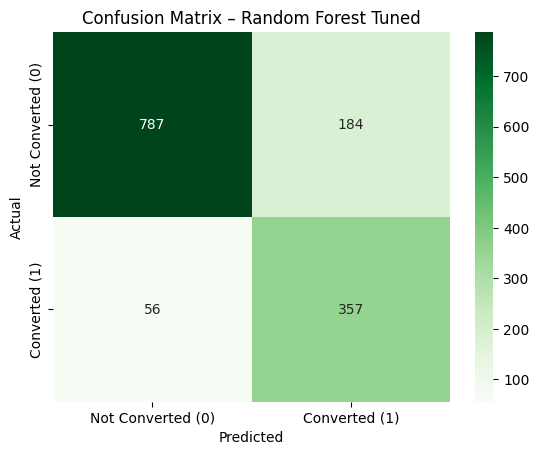

In [113]:
cm = confusion_matrix(y_test, y_pred_rf_te)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Converted (0)', 'Converted (1)'],
            yticklabels=['Not Converted (0)', 'Converted (1)'])
plt.title('Confusion Matrix – Random Forest Tuned')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

**Observations**

- True Negatives (787)- The model correctly identified 787 leads who did not convert. This means it's still strong at recognizing non-converters.
- False Positives (184)- These are leads incorrectly predicted as “converted” even though they weren't. About 18.9% of non-converted leads were wrongly classified, a moderate trade-off for higher recall.
- False Negatives (56) - Only 56 real converters were missed by the model. This is a huge improvement from previous models (especially the baseline Decision Tree), confirming the model's high recall ability.
- True Positives (357) - The model correctly detected 357 actual conversions — that's about 86% of all true converters. This is consistent with the recall value (≈ 0.864).

### Importance of features for the Pruned (Tuned) Random Forest

In [110]:
print(
    pd.DataFrame(
        rf_tuned.feature_importances_,   # importance values from the tuned RF model
        columns=["Importance"],          # column label
        index=X_train.columns            # feature names
    ).sort_values(by="Importance", ascending=False)
)


                                Importance
time_spent_on_website             0.306413
first_interaction_Website         0.280369
profile_completed_Medium          0.199510
age                               0.061485
last_activity_Phone Activity      0.044509
current_occupation_Unemployed     0.037606
last_activity_Website Activity    0.025287
current_occupation_Student        0.016158
page_views_per_visit              0.014199
website_visits                    0.011721
educational_channels_Yes          0.001620
print_media_type1_Yes             0.000490
digital_media_Yes                 0.000339
profile_completed_Low             0.000292
print_media_type2_Yes             0.000000
referral_Yes                      0.000000


### Plotting the feature importance Pruned (Tuned) Decision Tree

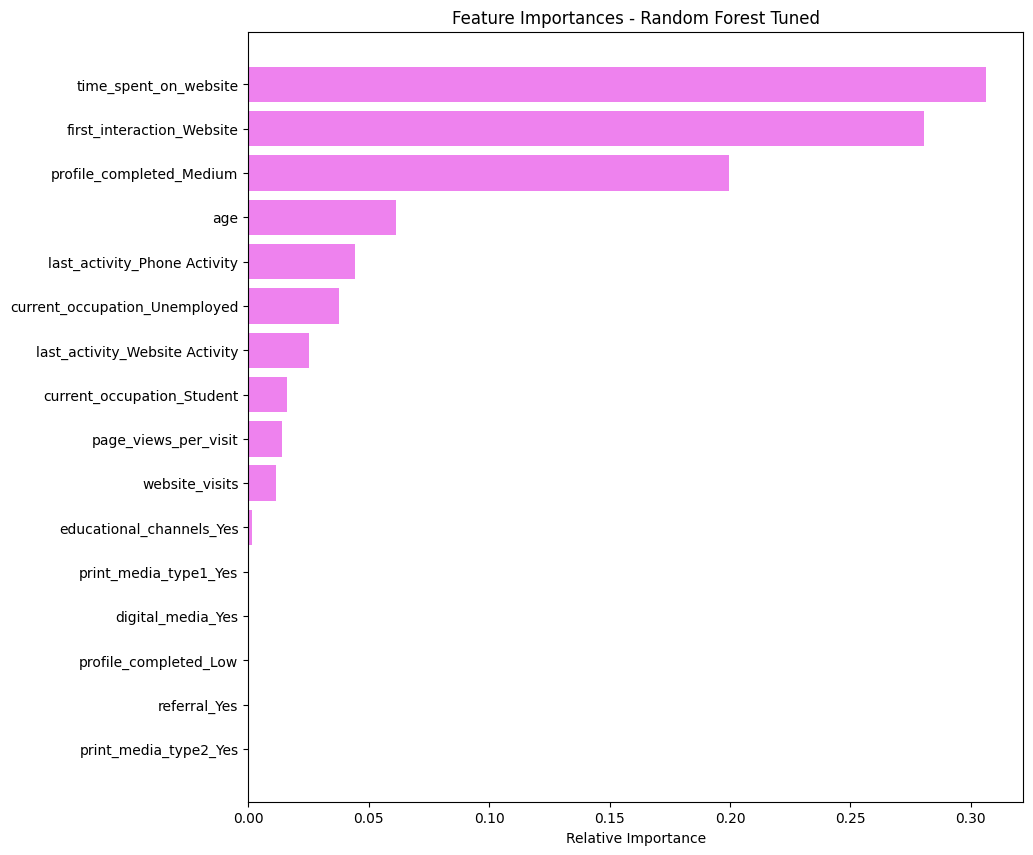

In [114]:
# Extract feature importances from the tuned Random Forest
importances = rf_tuned.feature_importances_

# Sort the feature indices by importance value
indices = np.argsort(importances)

# Create the plot
plt.figure(figsize=(10, 10))
plt.title('Feature Importances - Random Forest Tuned')

# Horizontal bar chart of importances
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')

# Add feature names on the y-axis
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])

# Label the x-axis
plt.xlabel('Relative Importance')

# Show the plot
plt.show()


**Observations**

- time_spent_on_website is the strongest predictor, confirming that users who spend more time navigating the website are much more likely to convert. This aligns with previous models and reinforces that engagement duration is the key behavioral indicator of conversion intent.
- first_interaction_Website follows closely, showing that leads whose initial contact occurred through the website tend to have a higher likelihood of conversion. This suggests that the digital experience at the first touchpoint is crucial.
- profile_completed_Medium also plays a major role. Leads who partially complete their profiles are significantly more likely to convert compared to those with minimal information. This reflects their genuine interest and engagement level.
- age and last_activity_Phone Activity contribute meaningfully as well. Age might be correlated with purchasing power or decision-making ability, while recent phone interactions strengthen the conversion potential through personal communication.
- current_occupation_Unemployed, last_activity_Website Activity, and current_occupation_Student have moderate influence, capturing behavioral nuances among specific demographic groups.
- Finally, variables such as page_views_per_visit, website_visits, and all media-related features (like digital_media_Yes, print_media_type1_Yes, educational_channels_Yes) have very low importance. This suggests that passive exposure to marketing channels contributes little compared to active engagement on the website.

#### Comparing both models

In [115]:
rf_base_metrics  = get_metrics(rf,       X_train, y_train, X_test, y_test)
rf_tuned_metrics = get_metrics(rf_tuned, X_train, y_train, X_test, y_test)

comparison_df = pd.DataFrame({
    "Metric": list(rf_base_metrics.keys()),
    "Random Forest (Baseline)": list(rf_base_metrics.values()),
    "Random Forest (Tuned)":    list(rf_tuned_metrics.values())
})

print("=== Comparison: Random Forest Baseline vs Tuned ===")
display(
    comparison_df.style
        .format({"Random Forest (Baseline)": "{:.3f}",
                 "Random Forest (Tuned)": "{:.3f}"})
        .set_caption("Model Performance Comparison")
        .background_gradient(cmap="Purples", axis=None)
)


=== Comparison: Random Forest Baseline vs Tuned ===


,Metric,Random Forest (Baseline),Random Forest (Tuned)
0,Train Accuracy,1.000,0.836
1,Test Accuracy,0.852,0.827
2,Precision (class 1),0.775,0.660
3,Recall (class 1),0.709,0.864
4,F1-score (class 1),0.741,0.748
5,ROC-AUC,0.911,0.920


**Observations**

- Train Accuracy:
Baseline: 1.000 - Tuned: 0.836

The baseline model perfectly fits the training data, a clear sign of overfitting. The tuned model shows lower train accuracy, which is healthy because it generalizes better.

- Test Accuracy
Baseline: 0.852 - Tuned: 0.827

There is a small decrease in test accuracy, but the tuned model still performs consistently well across unseen data, an expected trade-off after regularization.

- Precision (class 1)
Baseline: 0.775 - Tuned: 0.660

Precision dropped, meaning the tuned model generates slightly more false positives. However, this is often acceptable if your main goal is to detect as many true conversions as possible.

- Recall (class 1)
Baseline: 0.709 - Tuned: 0.864

Huge improvement here, the tuned model correctly identifies many more real conversions. This confirms the hyperparameter tuning successfully improved recall, which was our optimization objective.

- F1-Score (class 1)
Baseline: 0.741 - Tuned: 0.748

The overall balance between precision and recall slightly improved, reflecting a more effective model in capturing conversions without drastically increasing false alarms.

- ROC-AUC
Baseline: 0.911 - Tuned: 0.920

The tuned model shows a marginally higher ROC-AUC, meaning it’s better at ranking positive and negative cases overall.


-- In conclusion, The baseline model is clearly overfitted, it memorizes the training data with perfect accuracy but loses generalization. The tuned Random Forest offers a more balanced, generalizable model with stronger recall and similar discrimination power (AUC). This makes the tuned model a better choice when your goal is to maximize detection of true conversions, even if it means slightly lowering precision.



## Comparing all 4 models: Decision Tree, Decision Tree Pruned, Random Forest and Random Forest Tuned.

In [117]:
dt_base_metrics   = get_metrics(dt, X_train, y_train, X_test, y_test)
dt_tuned_metrics  = get_metrics(d_tree_tuned, X_train, y_train, X_test, y_test)
rf_base_metrics   = get_metrics(rf, X_train, y_train, X_test, y_test)
rf_tuned_metrics  = get_metrics(rf_tuned, X_train, y_train, X_test, y_test)

# Combine into one DataFrame
comparison_df = pd.DataFrame({
    "Metric": list(dt_base_metrics.keys()),
    "Decision Tree (Baseline)": list(dt_base_metrics.values()),
    "Decision Tree (Pruend)": list(dt_tuned_metrics.values()),
    "Random Forest (Baseline)": list(rf_base_metrics.values()),
    "Random Forest (Tuned)": list(rf_tuned_metrics.values())
})

# Display comparison table
print("=== Comparison: Decision Tree & Random Forest Models ===")
display(
    comparison_df.style
        .format({
            "Decision Tree (Baseline)": "{:.3f}",
            "Decision Tree (Tuned)": "{:.3f}",
            "Random Forest (Baseline)": "{:.3f}",
            "Random Forest (Tuned)": "{:.3f}"
        })
        .set_caption("Model Performance Comparison (All Models)")
        .background_gradient(cmap="Purples", axis=None)
)

=== Comparison: Decision Tree & Random Forest Models ===


,Metric,Decision Tree (Baseline),Decision Tree (Pruend),Random Forest (Baseline),Random Forest (Tuned)
0,Train Accuracy,1.000,0.789653,1.000,0.836
1,Test Accuracy,0.803,0.789017,0.852,0.827
2,Precision (class 1),0.653,0.597111,0.775,0.660
3,Recall (class 1),0.724,0.900726,0.709,0.864
4,F1-score (class 1),0.687,0.718147,0.741,0.748
5,ROC-AUC,0.781,0.878733,0.911,0.920


**Observations**

- Across all models, the Random Forest (Tuned) delivers the best overall performance and generalization ability.

- Decision Tree (Baseline) and Random Forest (Baseline) both show perfect or near-perfect training accuracy (1.0), which indicates overfitting, they memorize the training data but risk poor generalization.

- The Decision Tree (Tuned) improves recall significantly and reduces overfitting, but its overall accuracy and AUC remain slightly below the Random Forest models.
- The Random Forest (Tuned) achieves the best balance between precision and recall, with a very high recall (0.864), meaning it successfully identifies most converted leads, and the highest ROC-AUC (0.920), showing superior discrimination between classes. Although its precision (0.66) is slightly lower, this is acceptable given the goal of maximizing recall and overall predictive power.

In conclusion, the Random Forest (Tuned) model is the most effective one. It generalizes well, avoids overfitting, and provides the best trade-off between recall, F1-score, and ROC-AUC — making it the recommended model for predicting conversions.

## Actionable Insights and Recommendations

By focusing on digital engagement, profile completion, and targeted communication, ExtraaLearn can significantly improve lead-to-customer conversion rates.
The Tuned Random Forest model not only provides accurate predictions but also actionable insights to guide strategic decisions — transforming the lead management process from reactive to data-driven and proactive.

### 1. Focus on Digital Engagement

Time spent on the website and first interaction via the website are consistently the most important predictors across all models. Leads who spend more time browsing and start their journey through the website show a much higher likelihood of conversion.

- Recommendation:

Improve the website experience, make navigation smoother, highlight course benefits early, and include clear calls to action like “Enroll Now,” “Book a Free Demo”, etc.

Use personalized follow-ups (emails or remarketing) for leads who spend significant time on the site but don't convert immediately.

### 2. Encourage Profile Completion

Leads with medium or high profile completion levels convert far more often than those with low completion. This suggests that profile engagement is a strong proxy for intent.

- Recommendation:

Introduce progress bars, incentives, or reminders encouraging users to complete their profiles.

Consider restricting access to premium content or free demos until a minimum completion threshold is reached.

### 3. Strengthen Conversion Through Personal Contact

Last_activity_Phone Activity ranks among the most relevant behavioral variables, especially in the tuned Random Forest model. Direct human interaction (calls or SMS) helps move leads closer to conversion.

- Recommendation:

Prioritize phone outreach for leads showing high engagement but who haven't yet converted.

### 4. Leverage Referral Programs

Although only ~2% of leads come from referrals, their conversion rate exceeds 65%, making this channel extremely effective.

- Recommendation:

Launch or reinforce a referral incentive program (discounts, vouchers, or free sessions for both the referrer and the referred).

Highlight referral opportunities prominently in the user dashboard and follow-up emails.

### 5. Reallocate Marketing Budget

Traditional advertising channels like print and magazines contribute minimally to conversions. Their reach is small, and feature importance is near zero.

- Recommendation:

Gradually shift investment from print media to digital campaigns (social media, retargeting, SEO).

Use model predictions to focus ads on high-probability segments like professionals aged 35 to 55 with medium-to-high engagement.

### 6. Target the Right Audience

Professionals have the highest conversion rates (≈35%), followed by unemployed leads (~26%), while students convert the least (~12%).

- Recommendation:

Prioritize campaigns targeting working professionals, especially mid-career individuals seeking upskilling.

For students, consider introducing scholarships or flexible payment options to improve affordability and conversion potential.